# Практическая работа №2. Визуализация данных в Python

В работе исследуется дневной набор Bike Sharing за 2011-2012 годы.
Для многомерной визуализации используется встроенный набор рукописных
цифр `sklearn.datasets.load_digits` (1797 объектов, 64 признака).

In [1]:
from __future__ import annotations

import io
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sklearn
import umap
from matplotlib.lines import Line2D
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE, trustworthiness
from sklearn.preprocessing import StandardScaler


ROOT = Path.cwd()
if not (ROOT / "data" / "day.csv").exists():
    ROOT = Path(__file__).resolve().parents[1]

DATA_PATH = ROOT / "data" / "day.csv"
OUTPUT = ROOT / "output"
FIGURES = OUTPUT / "figures"
INTERACTIVE = OUTPUT / "interactive"
FIGURES.mkdir(parents=True, exist_ok=True)
INTERACTIVE.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "figure.dpi": 120,
    }
)

## 1. Загрузка и описание данных

`day.csv` содержит ежедневные показатели системы Capital Bikeshare в
Вашингтоне: дату, сезон, календарные признаки, погоду, число случайных и
зарегистрированных пользователей и общее число поездок.

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["dteday"])

print("Размер исходной таблицы:", df.shape)
print("\nПервые пять строк:")
print(df.head().to_string(index=False))

buffer = io.StringIO()
df.info(buf=buffer, memory_usage="deep")
print("\nРезультат info():")
print(buffer.getvalue())

missing = df.isna().sum()
duplicates = int(df.duplicated().sum())
print("Пропуски по столбцам:")
print(missing.to_string())
print("Полные дубликаты:", duplicates)

Размер исходной таблицы: (731, 16)

Первые пять строк:
 instant     dteday  season  yr  mnth  holiday  weekday  workingday  weathersit     temp    atemp      hum  windspeed  casual  registered  cnt
       1 2011-01-01       1   0     1        0        6           0           2 0.344167 0.363625 0.805833   0.160446     331         654  985
       2 2011-01-02       1   0     1        0        0           0           2 0.363478 0.353739 0.696087   0.248539     131         670  801
       3 2011-01-03       1   0     1        0        1           1           1 0.196364 0.189405 0.437273   0.248309     120        1229 1349
       4 2011-01-04       1   0     1        0        2           1           1 0.200000 0.212122 0.590435   0.160296     108        1454 1562
       5 2011-01-05       1   0     1        0        3           1           1 0.226957 0.229270 0.436957   0.186900      82        1518 1600

Результат info():
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data co

Пропусков и полных дубликатов нет. Для интерпретации нормированные погодные
признаки переводятся в исходные единицы, а числовые коды получают подписи.

In [3]:
season_names = {1: "Весна", 2: "Лето", 3: "Осень", 4: "Зима"}
weather_names = {
    1: "Ясно или малооблачно",
    2: "Туман или облачно",
    3: "Небольшие осадки",
    4: "Сильные осадки",
}

clean = df.copy()
clean["season_name"] = clean["season"].map(season_names).astype("category")
clean["weather_name"] = clean["weathersit"].map(weather_names).astype("category")
clean["temp_c"] = clean["temp"] * 41
clean["atemp_c"] = clean["atemp"] * 50
clean["humidity_pct"] = clean["hum"] * 100
clean["windspeed_kmh"] = clean["windspeed"] * 67

assert int(clean.isna().sum().sum()) == 0
assert (clean["casual"] + clean["registered"] == clean["cnt"]).all()

clean.to_csv(OUTPUT / "bike_sharing_visualization_clean.csv", index=False)
clean.to_parquet(OUTPUT / "bike_sharing_visualization_clean.parquet", index=False)

data_summary = {
    "rows": int(len(clean)),
    "columns_source": int(df.shape[1]),
    "date_min": clean["dteday"].min().date().isoformat(),
    "date_max": clean["dteday"].max().date().isoformat(),
    "missing_values": int(clean.isna().sum().sum()),
    "duplicate_rows": duplicates,
    "total_rentals": int(clean["cnt"].sum()),
    "mean_daily_rentals": round(float(clean["cnt"].mean()), 2),
    "median_daily_rentals": round(float(clean["cnt"].median()), 2),
    "max_daily_rentals": int(clean["cnt"].max()),
}
print("Сводка:", json.dumps(data_summary, ensure_ascii=False, indent=2))

Сводка: {
  "rows": 731,
  "columns_source": 16,
  "date_min": "2011-01-01",
  "date_max": "2012-12-31",
  "missing_values": 0,
  "duplicate_rows": 0,
  "total_rentals": 3292679,
  "mean_daily_rentals": 4504.35,
  "median_daily_rentals": 4548.0,
  "max_daily_rentals": 8714
}


## 2. Столбчатая диаграмма Plotly

Чтобы подписи дат оставались читаемыми, дневные поездки агрегируются по
месяцам. Цвет каждого столбца определяется тем же количественным показателем.

In [4]:
monthly = (
    clean.set_index("dteday")
    .resample("MS")[["casual", "registered", "cnt"]]
    .sum()
    .reset_index()
)
monthly["month_label"] = monthly["dteday"].dt.strftime("%Y-%m")

bar = go.Figure(
    data=[
        go.Bar(
            x=monthly["month_label"],
            y=monthly["cnt"],
            name="Поездки",
            marker=dict(
                color=monthly["cnt"],
                coloraxis="coloraxis",
                line=dict(color="black", width=2),
            ),
            hovertemplate="Месяц: %{x}<br>Поездки: %{y:,}<extra></extra>",
        )
    ]
)
bar.update_layout(
    title=dict(text="Количество поездок по месяцам", x=0.5, font=dict(size=20)),
    xaxis=dict(
        title=dict(text="Месяц", font=dict(size=16)),
        tickfont=dict(size=14),
        tickangle=315,
        gridwidth=2,
        gridcolor="ivory",
    ),
    yaxis=dict(
        title=dict(text="Количество поездок", font=dict(size=16)),
        tickfont=dict(size=14),
        gridwidth=2,
        gridcolor="ivory",
        rangemode="tozero",
    ),
    coloraxis=dict(colorscale="Viridis", colorbar=dict(title="Поездки")),
    template="plotly_white",
    autosize=True,
    height=700,
    margin=dict(l=10, r=10, t=65, b=10),
    showlegend=False,
)
bar.write_html(INTERACTIVE / "01_monthly_bar.html", include_plotlyjs="cdn")
bar.write_image(FIGURES / "01_monthly_bar.png", width=1400, height=700, scale=1.5)
bar.show()

Максимум месячного спроса приходится на сентябрь 2012 года. В 2012 году
почти все месяцы заметно выше соответствующих месяцев 2011 года.

## 3. Круговая диаграмма Plotly

In [5]:
season_totals = (
    clean.groupby("season_name", observed=True)["cnt"]
    .sum()
    .reindex(["Весна", "Лето", "Осень", "Зима"])
)

normalized = (season_totals - season_totals.min()) / (
    season_totals.max() - season_totals.min()
)
pie_colors = [
    f"rgb({int(68 + 185 * v)}, {int(1 + 230 * v)}, {int(84 + 60 * (1-v))})"
    for v in normalized
]

pie = go.Figure(
    data=[
        go.Pie(
            labels=season_totals.index,
            values=season_totals.values,
            textinfo="label+percent",
            textfont=dict(size=14),
            marker=dict(colors=pie_colors, line=dict(color="black", width=2)),
            sort=False,
            hovertemplate="%{label}: %{value:,} поездок (%{percent})<extra></extra>",
        )
    ]
)
pie.update_layout(
    title=dict(text="Распределение поездок по сезонам", x=0.5, font=dict(size=20)),
    template="plotly_white",
    autosize=True,
    height=700,
    margin=dict(l=10, r=10, t=65, b=10),
    showlegend=False,
)
pie.write_html(INTERACTIVE / "02_season_pie.html", include_plotlyjs="cdn")
pie.write_image(FIGURES / "02_season_pie.png", width=1100, height=700, scale=1.5)
pie.show()

Наибольшая доля поездок приходится на осень, наименьшая — на весну. Разрыв
между сезонами заметен, но ни одна категория не является исчезающе малой.

## 4. Линейные графики Matplotlib

Временной параметр — месяц; зависимые показатели — число поездок случайных,
зарегистрированных и всех пользователей.

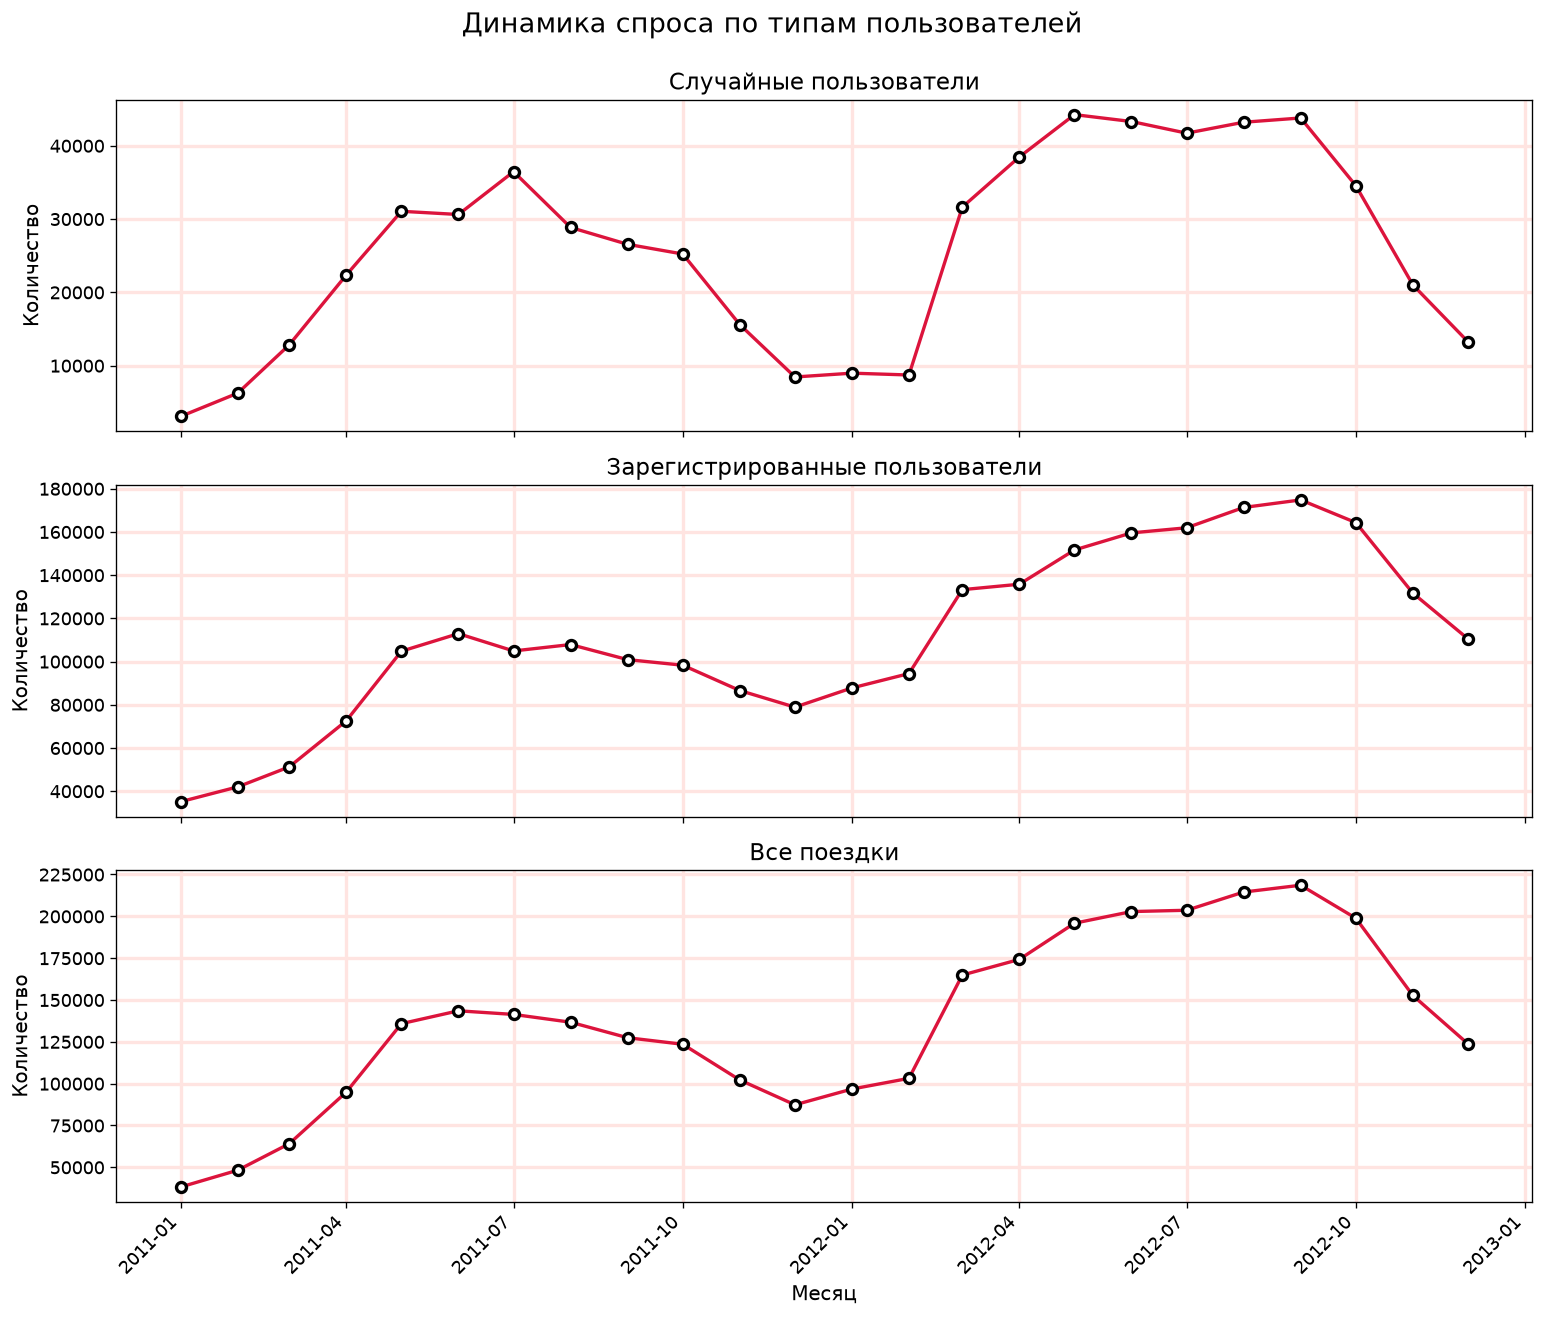

Корреляции месячных рядов:
            casual  registered    cnt
casual       1.000       0.864  0.922
registered   0.864       1.000  0.991
cnt          0.922       0.991  1.000


In [6]:
series = [
    ("casual", "Случайные пользователи"),
    ("registered", "Зарегистрированные пользователи"),
    ("cnt", "Все поездки"),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
for ax, (column, title) in zip(axes, series, strict=True):
    ax.plot(
        monthly["dteday"],
        monthly[column],
        color="crimson",
        linewidth=2,
        marker="o",
        markersize=6,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=2,
    )
    ax.set_title(title)
    ax.set_ylabel("Количество")
    ax.grid(linewidth=2, color="mistyrose")
axes[-1].set_xlabel("Месяц")
fig.suptitle("Динамика спроса по типам пользователей", fontsize=16, y=0.995)
fig.autofmt_xdate(rotation=45)
fig.tight_layout()
fig.savefig(FIGURES / "03_monthly_lines.png", bbox_inches="tight")
plt.show()

monthly_correlations = monthly[["casual", "registered", "cnt"]].corr().round(3)
print("Корреляции месячных рядов:")
print(monthly_correlations.to_string())

Все три ряда имеют общую сезонную форму и растут во втором году. Основной
вклад в общее число поездок вносит зарегистрированная аудитория; корреляция
месячных рядов `registered` и `cnt` выше, чем у `casual` и `cnt`.

## 5. t-SNE для набора рукописных цифр

In [7]:
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target
X_scaled = StandardScaler().fit_transform(X)

print("Размер набора digits:", X.shape)
print("Классы:", np.unique(y))
print("Пропуски:", int(np.isnan(X_scaled).sum()))

perplexities = [5, 30, 50]
tsne_results: dict[int, np.ndarray] = {}
timings: list[dict[str, float | int | str]] = []

for perplexity in perplexities:
    started = time.perf_counter()
    model = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )
    embedding = model.fit_transform(X_scaled)
    elapsed = time.perf_counter() - started
    quality = trustworthiness(X_scaled, embedding, n_neighbors=10)
    tsne_results[perplexity] = embedding
    timings.append(
        {
            "algorithm": "t-SNE",
            "parameters": f"perplexity={perplexity}",
            "seconds": round(elapsed, 4),
            "trustworthiness_k10": round(float(quality), 4),
        }
    )
    print(
        f"t-SNE perplexity={perplexity}: {elapsed:.3f} s, "
        f"trustworthiness@10={quality:.4f}, KL={model.kl_divergence_:.4f}"
    )

Размер набора digits: (1797, 64)
Классы: [0 1 2 3 4 5 6 7 8 9]
Пропуски: 0
t-SNE perplexity=5: 1.407 s, trustworthiness@10=0.9807, KL=0.9776
t-SNE perplexity=30: 1.520 s, trustworthiness@10=0.9864, KL=0.8372
t-SNE perplexity=50: 1.929 s, trustworthiness@10=0.9857, KL=0.7749


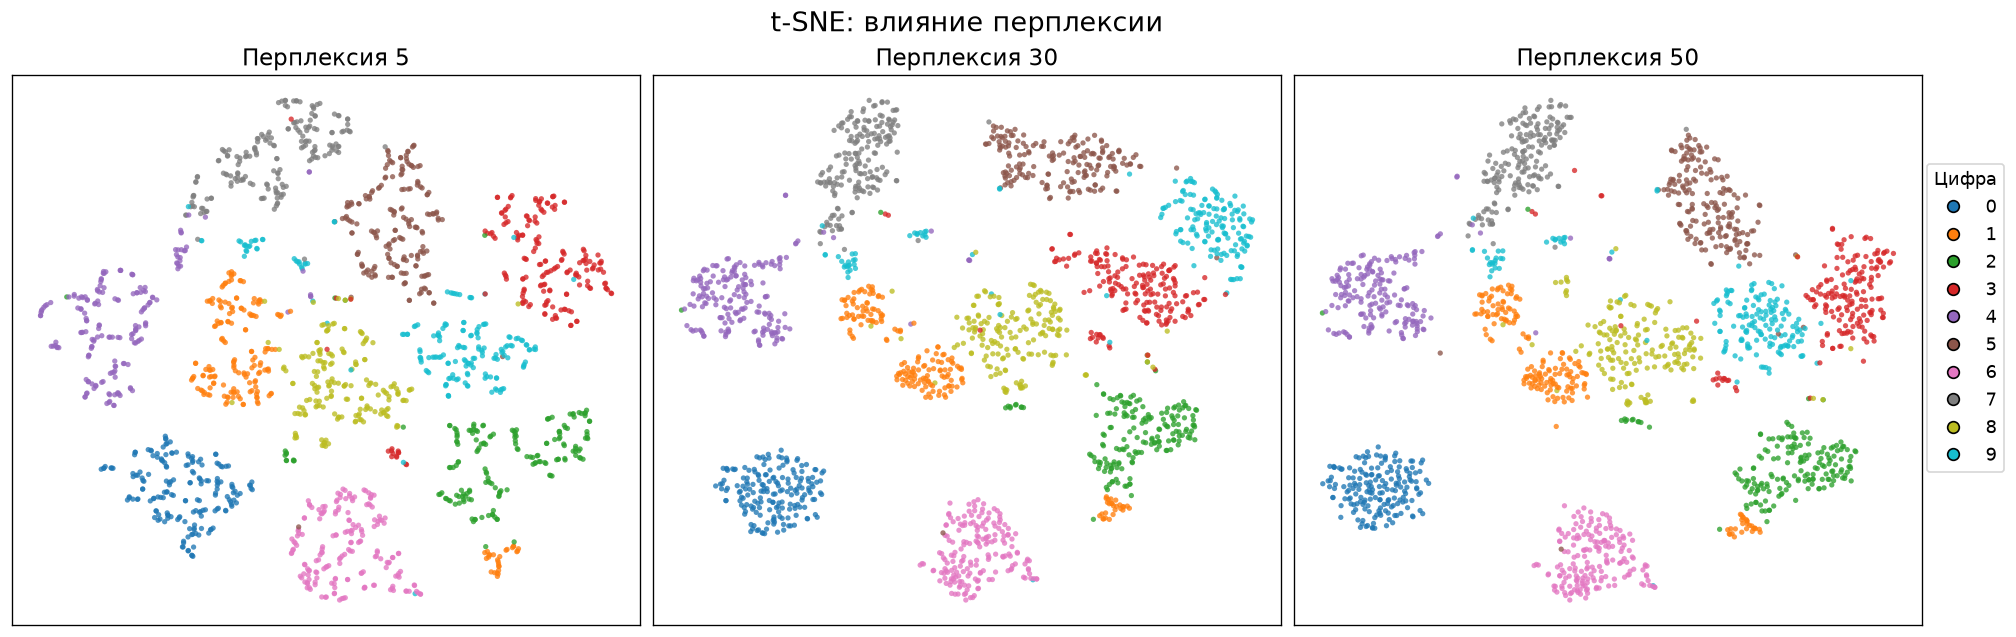

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), constrained_layout=True)
for ax, perplexity in zip(axes, perplexities, strict=True):
    embedding = tsne_results[perplexity]
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=y,
        cmap="tab10",
        s=10,
        alpha=0.78,
        linewidths=0,
    )
    ax.set_title(f"Перплексия {perplexity}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("t-SNE: влияние перплексии", fontsize=16)
handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=plt.cm.tab10(i),
           markersize=7, label=str(i))
    for i in range(10)
]
fig.legend(handles=handles, title="Цифра", loc="center right", bbox_to_anchor=(1.045, 0.5))
fig.savefig(FIGURES / "04_tsne_perplexities.png", bbox_inches="tight")
plt.show()

При перплексии 5 локальные подгруппы сильнее дробятся. Значения 30 и 50
формируют более цельные кластеры; некоторые классы всё равно частично
пересекаются из-за сходства начертания цифр.

## 6. UMAP с разными параметрами

In [9]:
umap_configs = [(5, 0.0), (15, 0.1), (50, 0.5)]
umap_results: dict[tuple[int, float], np.ndarray] = {}

for n_neighbors, min_dist in umap_configs:
    started = time.perf_counter()
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="euclidean",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    embedding = reducer.fit_transform(X_scaled)
    elapsed = time.perf_counter() - started
    quality = trustworthiness(X_scaled, embedding, n_neighbors=10)
    umap_results[(n_neighbors, min_dist)] = embedding
    timings.append(
        {
            "algorithm": "UMAP",
            "parameters": f"n_neighbors={n_neighbors}, min_dist={min_dist}",
            "seconds": round(elapsed, 4),
            "trustworthiness_k10": round(float(quality), 4),
        }
    )
    print(
        f"UMAP n_neighbors={n_neighbors}, min_dist={min_dist}: "
        f"{elapsed:.3f} s, trustworthiness@10={quality:.4f}"
    )

UMAP n_neighbors=5, min_dist=0.0: 8.113 s, trustworthiness@10=0.9780
UMAP n_neighbors=15, min_dist=0.1: 2.413 s, trustworthiness@10=0.9768
UMAP n_neighbors=50, min_dist=0.5: 2.947 s, trustworthiness@10=0.9618


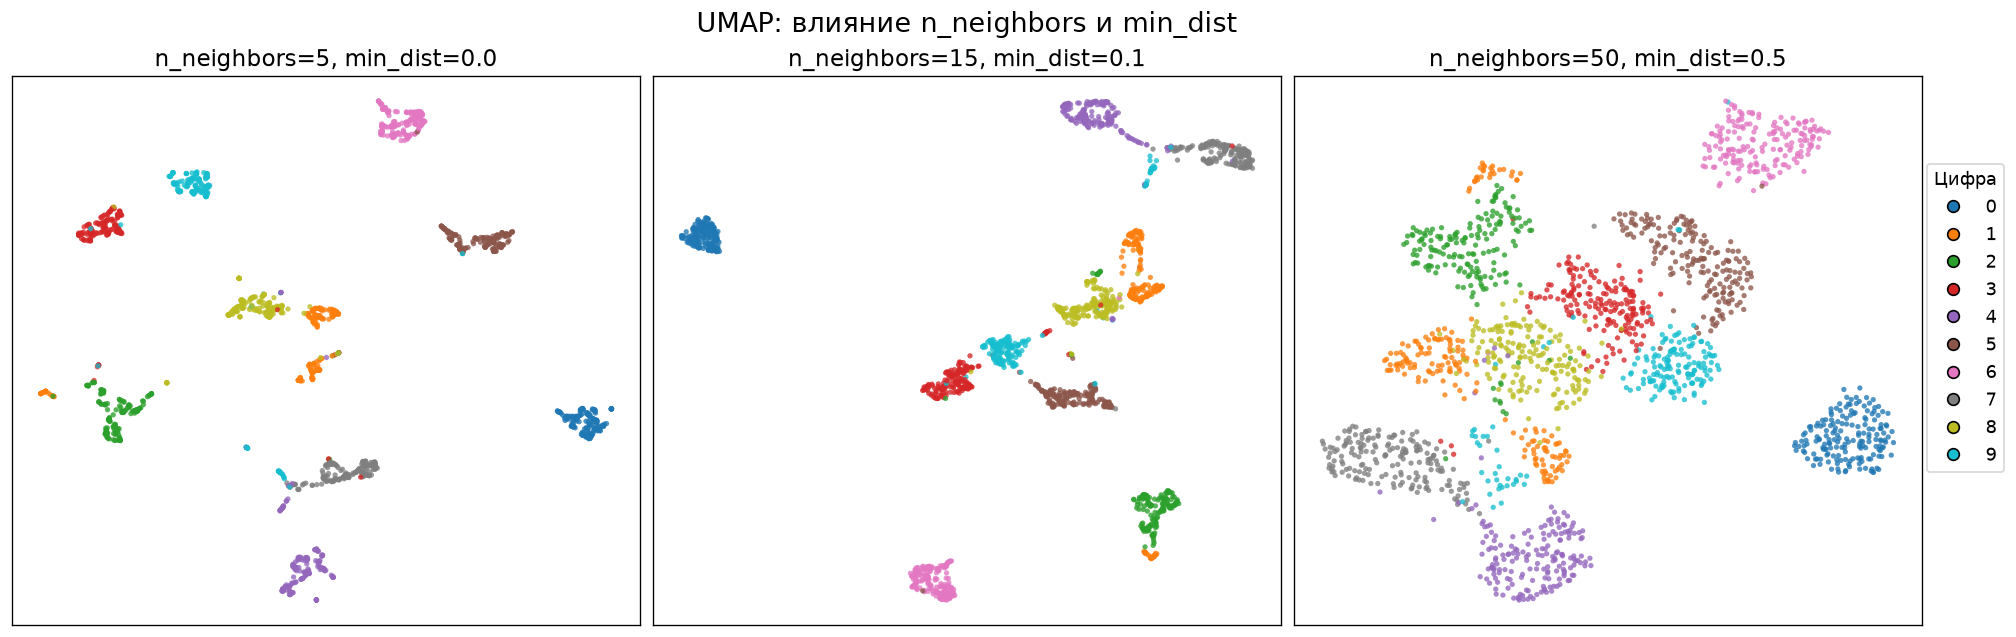

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), constrained_layout=True)
for ax, config in zip(axes, umap_configs, strict=True):
    embedding = umap_results[config]
    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=y,
        cmap="tab10",
        s=10,
        alpha=0.78,
        linewidths=0,
    )
    ax.set_title(f"n_neighbors={config[0]}, min_dist={config[1]}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("UMAP: влияние n_neighbors и min_dist", fontsize=16)
fig.legend(handles=handles, title="Цифра", loc="center right", bbox_to_anchor=(1.045, 0.5))
fig.savefig(FIGURES / "05_umap_parameters.png", bbox_inches="tight")
plt.show()

Малое число соседей и `min_dist=0` дают компактные локальные группы. При
увеличении обоих параметров точки распределяются свободнее, а глобальная
взаимная ориентация классов становится заметнее.

## 7. Сравнение времени и качества локальной структуры

algorithm                   parameters  seconds  trustworthiness_k10
    t-SNE                 perplexity=5   1.4072               0.9807
    t-SNE                perplexity=30   1.5196               0.9864
    t-SNE                perplexity=50   1.9295               0.9857
     UMAP  n_neighbors=5, min_dist=0.0   8.1133               0.9780
     UMAP n_neighbors=15, min_dist=0.1   2.4129               0.9768
     UMAP n_neighbors=50, min_dist=0.5   2.9469               0.9618


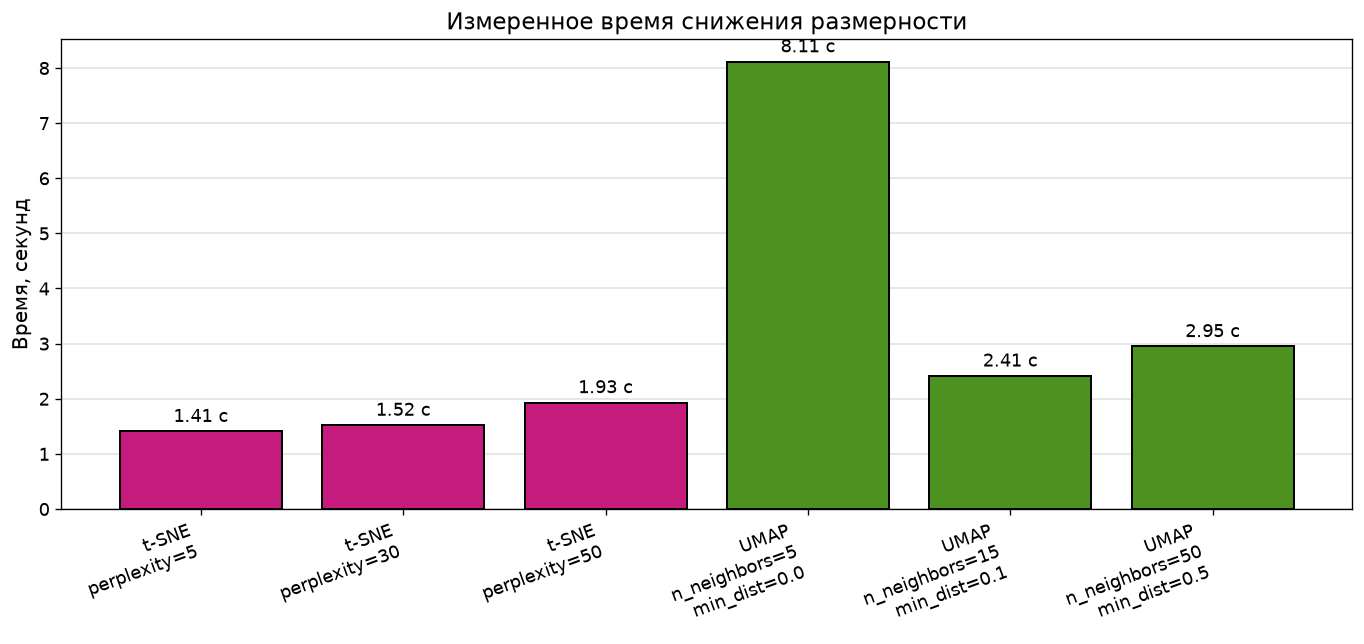

{
  "python": "3.12.14",
  "pandas": "3.0.5",
  "numpy": "2.5.3",
  "matplotlib": "3.11.2",
  "plotly": "7.0.0",
  "scikit_learn": "1.9.1",
  "umap_learn": "0.5.12",
  "random_state": 42,
  "tsne_mean_seconds": 1.6188,
  "umap_mean_seconds": 4.491,
  "umap_to_tsne_ratio": 2.7744,
  "note": "Первый запуск UMAP включает JIT-компиляцию numba и поэтому обычно медленнее последующих."
}


In [11]:
timings_df = pd.DataFrame(timings)
timings_df.to_csv(OUTPUT / "dimension_reduction_timings.csv", index=False)
print(timings_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11.5, 5.5))
labels = [
    f"{row.algorithm}\n{row.parameters.replace(', ', chr(10))}"
    for row in timings_df.itertuples()
]
colors = ["#c51b7d" if name == "t-SNE" else "#4d9221" for name in timings_df["algorithm"]]
bars = ax.bar(labels, timings_df["seconds"], color=colors, edgecolor="black", linewidth=1.2)
ax.bar_label(bars, fmt="%.2f с", padding=3)
ax.set_ylabel("Время, секунд")
ax.set_title("Измеренное время снижения размерности")
ax.grid(axis="y", color="#e6e6e6", linewidth=1.2)
ax.set_axisbelow(True)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()
fig.savefig(FIGURES / "06_runtime_comparison.png", bbox_inches="tight")
plt.show()

tsne_mean = float(timings_df.loc[timings_df["algorithm"] == "t-SNE", "seconds"].mean())
umap_mean = float(timings_df.loc[timings_df["algorithm"] == "UMAP", "seconds"].mean())
runtime_summary = {
    "python": __import__("sys").version.split()[0],
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": __import__("matplotlib").__version__,
    "plotly": __import__("plotly").__version__,
    "scikit_learn": sklearn.__version__,
    "umap_learn": umap.__version__,
    "random_state": RANDOM_STATE,
    "tsne_mean_seconds": round(tsne_mean, 4),
    "umap_mean_seconds": round(umap_mean, 4),
    "umap_to_tsne_ratio": round(umap_mean / tsne_mean, 4),
    "note": "Первый запуск UMAP включает JIT-компиляцию numba и поэтому обычно медленнее последующих.",
}

summary = {
    "bike_sharing": data_summary,
    "season_totals": {str(k): int(v) for k, v in season_totals.items()},
    "monthly_peak": {
        "month": monthly.loc[monthly["cnt"].idxmax(), "month_label"],
        "rentals": int(monthly["cnt"].max()),
    },
    "monthly_correlations": monthly_correlations.to_dict(),
    "dimension_reduction": runtime_summary,
    "timings": timings,
}
(OUTPUT / "summary.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8"
)

print(json.dumps(runtime_summary, ensure_ascii=False, indent=2))

## 8. Итоговые выводы

- Спрос имеет выраженную сезонность и существенно вырос во втором году.
- Зарегистрированные пользователи формируют основную часть месячного спроса.
- Plotly удобен для интерактивной проверки точных значений; Matplotlib даёт
  полный контроль над статическим многопанельным рисунком.
- t-SNE чувствителен к перплексии и хорошо показывает локальные кластеры, но
  расстояния между удалёнными кластерами нельзя трактовать буквально.
- UMAP позволяет управлять балансом локальной и глобальной структуры через
  `n_neighbors` и `min_dist`; первый запуск включает JIT-компиляцию.